In [1]:
# ============================================================
# BLOQUE 1. Imports, configuración y carga de datos
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import auc

import statsmodels.formula.api as smf
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
np.random.seed(12345)

# ------------------------
# Carga de datos
# ------------------------
df = pd.read_stata("data/MASTER_MICS_FINAL.dta", convert_categoricals=False)

# Tratamiento y outcomes
T_col = "water_treatment"
outcomes = ["SomeRiskHome", "VeryHighRiskHome"]


In [2]:
# ============================================================
# BLOQUE 2. Definición de X_base y X_ext
# ============================================================

cat_vars = ["windex5", "country_cat", "WS1_g", "water_carrier_edu"]
cont_base = ["helevel"]
cont_ext = cont_base + [
    "Any_U5", "Girls_less_than15", "Boys_15or_less",
    "Pit_latrine", "Open_defecation"
]

# Dummies para categóricas
X_cat = pd.get_dummies(df[cat_vars], drop_first=True)

X_base_ml = pd.concat([X_cat, df[cont_base]], axis=1)
X_ext_ml = pd.concat([X_cat, df[cont_ext]], axis=1)

def make_ml_frames(Y_col, use_ext=True):
    """
    Construye df_ml con T, Y y X (base o extendido), sin NA.
    """
    if use_ext:
        X_ml = X_ext_ml
        X_cols = X_ext_ml.columns.tolist()
    else:
        X_ml = X_base_ml
        X_cols = X_base_ml.columns.tolist()
    
    df_ml = pd.concat(
        [df[[T_col, Y_col]].reset_index(drop=True),
         X_ml.reset_index(drop=True)],
        axis=1
    ).dropna()
    
    return df_ml, X_cols


# OLS

In [3]:
df['helevel'].value_counts()

helevel
2    24382
1    18003
0    14336
Name: count, dtype: int64

In [4]:
# ============================================================
# BLOQUE 3. OLS descriptivo (ATE homogéneo)
# ============================================================

def run_ols_outcome(Y_col):
    """
    Estima:
      - OLS base: Y ~ T + C(windex5) + C(helevel) + C(country_cat) + C(WS1_g)
      - OLS extendido: + resto de controles
    """
    formula_base = (
        f"{Y_col} ~ {T_col}"
        " + C(windex5) + C(helevel) + C(country_cat) + C(WS1_g)"
    )
    formula_ext = (
        f"{Y_col} ~ {T_col}"
        " + C(windex5) + C(helevel) + C(country_cat) + C(WS1_g)"
        " + Any_U5 + Girls_less_than15 + Boys_15or_less"
        " + Pit_latrine + Open_defecation + C(water_carrier_edu)"
    )
    
    mod_ols_base = smf.ols(formula=formula_base, data=df).fit(cov_type="HC1")
    mod_ols_ext = smf.ols(formula=formula_ext, data=df).fit(cov_type="HC1")
    
    print(f"\n===== OLS BASE para {Y_col} =====")
    print(mod_ols_base.summary())
    print(f"\n===== OLS EXTENDIDO para {Y_col} =====")
    print(mod_ols_ext.summary())
    
    return mod_ols_base, mod_ols_ext

ols_results = {}
for y in outcomes:
    ols_results[y] = run_ols_outcome(y)



===== OLS BASE para SomeRiskHome =====
                            OLS Regression Results                            
Dep. Variable:           SomeRiskHome   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     699.7
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:48:46   Log-Likelihood:                -23966.
No. Observations:               56721   AIC:                         4.801e+04
Df Residuals:                   56683   BIC:                         4.835e+04
Df Model:                          37                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

# DML Lineal

## No heterogeneity

In [11]:
# ============================================================
# BLOQUE 4.1 DML lineal sin heterogeneidad (ATE constante)
# ============================================================

def dml_linear_constant(Y_col, use_ext=True, n_splits=5):
    """
    DML lineal "simple":
      1) Residualiza T y Y respecto a X -> T_res, Y_res.
      2) Regresión lineal Y_res ~ T_res (un solo beta).
    """
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)   # binario
    T = df_ml[T_col].values.reshape(-1, 1)   # binario
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)  # E[T|X]
    g_hat = np.zeros(n)  # E[Y|X]
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        # Modelo para T | X (propensity score)
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]   # P(T=1|X)
        
        # Modelo para Y | X (outcome)
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]   # P(Y=1|X)
    
    # Residuales ortogonales
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    df_res = pd.DataFrame({"Y_res": Y_res, "T_res": T_res})
    mod_const = smf.ols("Y_res ~ T_res", data=df_res).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL (ATE constante) para {Y_col} =====")
    print(mod_const.summary())
    
    # Un solo beta -> un solo CATE (mismo para todos)
    cate_const = np.full(len(df_ml), mod_const.params["T_res"])
    
    df_out = df_ml.copy()
    df_out["T_res"] = T_res
    df_out["Y_res"] = Y_res
    df_out["cate_dml_linear_const"] = cate_const
    
    return mod_const, df_out, X_cols


dml_lin_const_results = {}
for y in outcomes:
    mod_const, df_const, Xc = dml_linear_constant(y, use_ext=True)
    dml_lin_const_results[y] = {"model": mod_const, "df": df_const, "X_cols": Xc}



===== DML LINEAL (ATE constante) para SomeRiskHome =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     160.0
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.26e-36
Time:                        21:54:17   Log-Likelihood:                -22561.
No. Observations:               55512   AIC:                         4.513e+04
Df Residuals:                   55510   BIC:                         4.514e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

## With Heterogeneity

In [12]:
# ============================================================
# BLOQUE 4.2 DML lineal con heterogeneidad (interacciones con todas las X)
# ============================================================

def dml_linear_hetero(Y_col, use_ext=True, n_splits=5):
    """
    DML lineal con heterogeneidad:
      1) Residualiza T y Y respecto a X -> T_res, Y_res.
      2) OLS: Y_res ~ T_res + X + T_res*X (todas las interacciones).
         => tau(x) = delta + sum_j theta_j x_j  (lineal en X).
    """
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)   # binario
    T = df_ml[T_col].values.reshape(-1, 1)   # binario
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)  # E[T|X]
    g_hat = np.zeros(n)  # E[Y|X]
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        # Modelo para T | X
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        # Modelo para Y | X
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    # Residuales ortogonales
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    # DataFrame para OLS con interacciones
    df_dml = pd.DataFrame({
        "Y_res": Y_res,
        "T_res": T_res
    })
    for j, col in enumerate(X_cols):
        df_dml[col] = X[:, j]
    
    x_part = " + ".join(X_cols)
    inter_part = " + ".join([f"T_res:{col}" for col in X_cols])
    formula = f"Y_res ~ T_res + {x_part} + {inter_part}"
    
    mod_hetero = smf.ols(formula=formula, data=df_dml).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL HETERO para {Y_col} =====")
    print(mod_hetero.summary())
    
    # CATE lineal: diferencia cuando T_res=1 vs T_res=0 (manteniendo X)
    df_t1 = df_dml.copy()
    df_t1["T_res"] = 1.0
    y_hat_1 = mod_hetero.predict(df_t1)
    
    df_t0 = df_dml.copy()
    df_t0["T_res"] = 0.0
    y_hat_0 = mod_hetero.predict(df_t0)
    
    cate_lin_hetero = y_hat_1 - y_hat_0
    df_dml["cate_dml_linear_hetero"] = cate_lin_hetero
    
    return mod_hetero, df_dml, X_cols


dml_lin_hetero_results = {}
for y in outcomes:
    mod_hetero, df_hetero, Xh = dml_linear_hetero(y, use_ext=True)
    dml_lin_hetero_results[y] = {"model": mod_hetero, "df": df_hetero, "X_cols": Xh}



===== DML LINEAL HETERO para SomeRiskHome =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     10.24
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           4.52e-34
Time:                        21:55:09   Log-Likelihood:                -22533.
No. Observations:               55512   AIC:                         4.511e+04
Df Residuals:                   55490   BIC:                         4.531e+04
Df Model:                          21                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

# Non Parametric

In [13]:
# ============================================================
# BLOQUE 5. DML NO PARAMÉTRICO (weight trick)
# ============================================================

from lightgbm import LGBMClassifier, LGBMRegressor

def dml_nonparam_weight_trick(Y_col, use_ext=True, n_splits=5):
    """
    DML no paramétrico:
      1) Residualiza T y Y -> T_res, Y_res.
      2) Weight trick:
           w = T_res**2
           y_star = Y_res / T_res - 1
      3) Ajusta ML: y_star ~ f(X) con pesos w.
         => tau(x) = f(x), permitiendo Y = g(X) + T * tau(X) con tau(X) no lineal.
    """
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)   # binario
    T = df_ml[T_col].values.reshape(-1, 1)   # binario
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)  # E[T|X]
    g_hat = np.zeros(n)  # E[Y|X]
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        # Modelo para T | X (propensity)
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        # Modelo para Y | X (outcome)
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    # Residuales ortogonales
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    # Weight trick
    eps = 1e-6
    w = T_res**2
    y_star = Y_res / np.clip(T_res, eps, None) - 1.0
    
    # Modelo no paramétrico para tau(X): REGRESOR (y_star es continuo)
    tau_model = LGBMRegressor(max_depth=3, n_estimators=400, verbose=-1)
    tau_model.fit(X, y_star, sample_weight=w)
    
    cate_tau = tau_model.predict(X)
    
    out = df_ml.copy()
    out["T_res"] = T_res
    out["Y_res"] = Y_res
    out["w_causal"] = w
    out["y_star"] = y_star
    out["cate_dml_nonparam"] = cate_tau
    
    return out, tau_model, X_cols


dml_np_results = {}
for y in outcomes:
    print(f"\n=== DML NO PARAMÉTRICO (weight trick) para {y} ===")
    out_df, tau_model, Xn = dml_nonparam_weight_trick(y, use_ext=True)
    dml_np_results[y] = {"df": out_df, "model": tau_model, "X_cols": Xn}



=== DML NO PARAMÉTRICO (weight trick) para SomeRiskHome ===

=== DML NO PARAMÉTRICO (weight trick) para VeryHighRiskHome ===


# Qini Curves

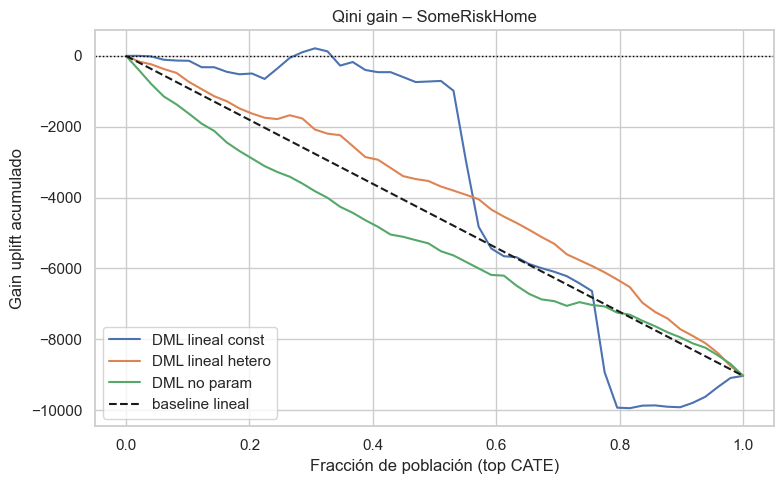

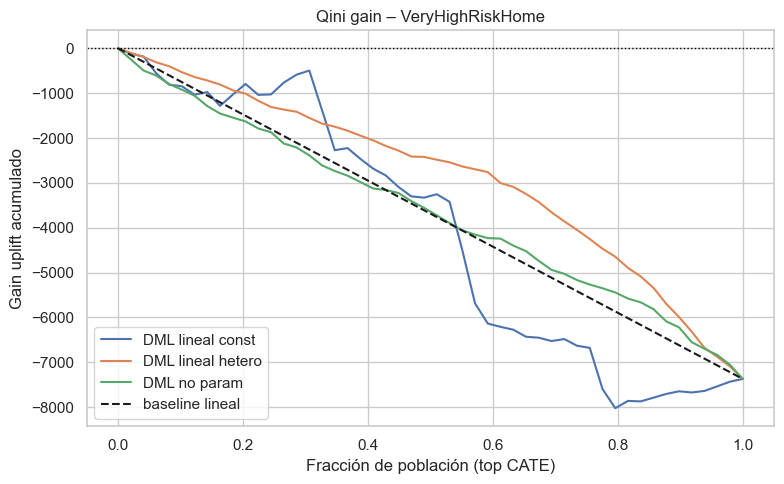

In [28]:
def qini_gain_facure(y, t, cate, n_points=50):
    order = np.argsort(-cate)
    y = y[order]
    t = t[order]

    n = len(y)
    treated = (t == 1)

    indices = (np.linspace(1, n, n_points)).astype(int) - 1
    fracs = []
    gains = []
    cum_y_t = cum_y_c = 0.0
    cum_t = cum_c = 0

    idx_set = set(indices.tolist())
    for idx in range(n):
        if treated[idx]:
            cum_y_t += y[idx]
            cum_t += 1
        else:
            cum_y_c += y[idx]
            cum_c += 1

        if idx in idx_set:
            k = idx + 1
            frac = k / n
            fracs.append(frac)
            if cum_t > 0 and cum_c > 0:
                ate = (cum_y_t / cum_t) - (cum_y_c / cum_c)
                gain = k * ate
            else:
                gain = 0.0
            gains.append(gain)

    return np.array(fracs), np.array(gains)


def plot_qini_gain(Y_col, n_points=50):
    """
    Qini gain (cumulative uplift) para:
      - DML lineal const
      - DML lineal hetero
      - DML no param
      + baseline lineal (ATE global)
    """
    base = pd.DataFrame(index=df.index)
    base["y"] = df[Y_col]
    base["t"] = df[T_col]

    base["cate_const"]  = dml_lin_const_results[Y_col]["df"]["cate_dml_linear_const"].reindex(base.index)
    base["cate_hetero"] = dml_lin_hetero_results[Y_col]["df"]["cate_dml_linear_hetero"].reindex(base.index)
    base["cate_np"]     = dml_np_results[Y_col]["df"]["cate_dml_nonparam"].reindex(base.index)

    base = base.dropna(subset=["y", "t", "cate_const", "cate_hetero", "cate_np"])

    y   = base["y"].values.astype(float)
    t   = base["t"].values.astype(int)
    c_c = base["cate_const"].values.astype(float)
    c_h = base["cate_hetero"].values.astype(float)
    c_n = base["cate_np"].values.astype(float)

    p_c, g_c = qini_gain_facure(y, t, c_c, n_points=n_points)
    p_h, g_h = qini_gain_facure(y, t, c_h, n_points=n_points)
    p_n, g_n = qini_gain_facure(y, t, c_n, n_points=n_points)

    plt.figure(figsize=(8, 5))
    plt.plot(p_c, g_c, label="DML lineal const",  color="C0")
    plt.plot(p_h, g_h, label="DML lineal hetero", color="C1")
    plt.plot(p_n, g_n, label="DML no param",      color="C2")

    # baseline: recta de 0 a gain_final (por ejemplo usando el modelo hetero)
    gain_final = g_h[-1]  # o np.mean([g_c[-1], g_h[-1], g_n[-1]])
    plt.plot([0, 1], [0, gain_final], "k--", label="baseline lineal")

    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain – {Y_col}")
    plt.xlabel("Fracción de población (top CATE)")
    plt.ylabel("Gain uplift acumulado")
    plt.legend()
    plt.tight_layout()
    plt.show()
    

# Ejecutar para ambos outcomes
for y in outcomes:
    plot_qini_gain(y, n_points=50)


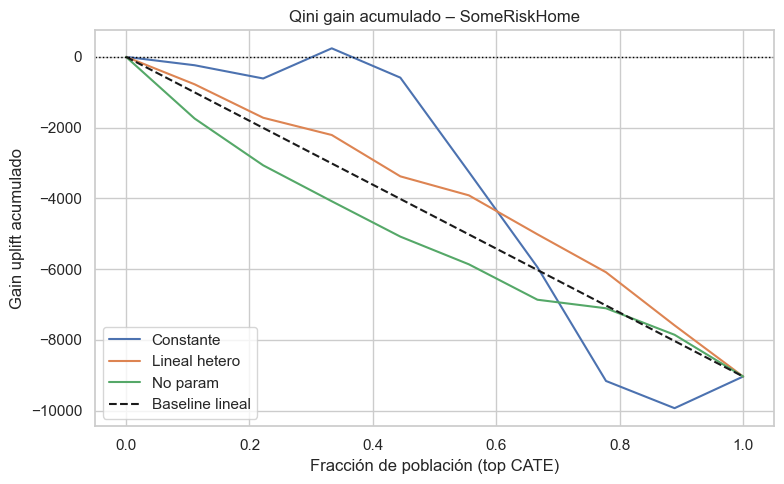

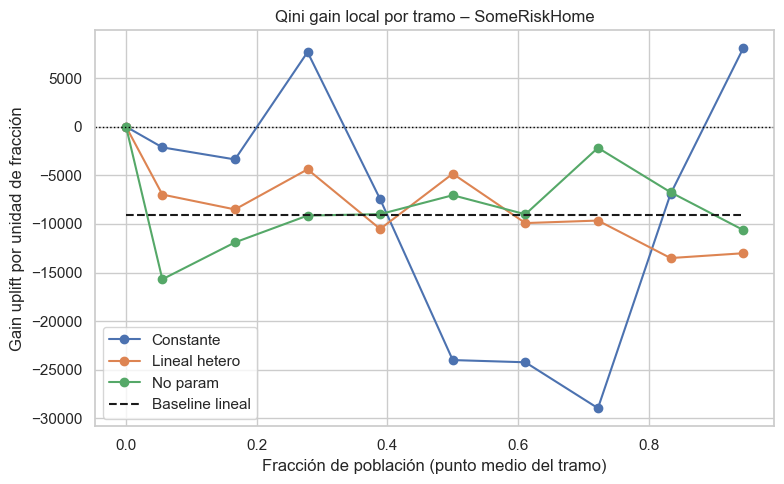

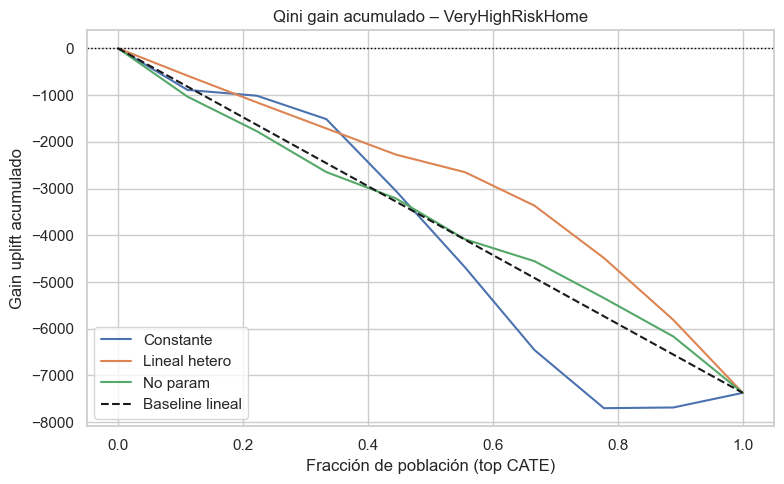

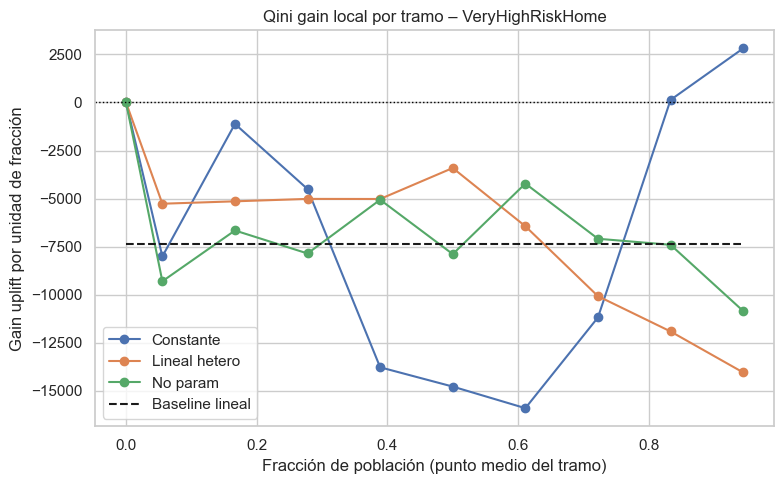

In [32]:
def qini_gain_facure(y, t, cate, n_points=50):
    order = np.argsort(-cate)
    y = y[order]
    t = t[order]

    n = len(y)
    treated = (t == 1)

    indices = (np.linspace(1, n, n_points)).astype(int) - 1
    fracs = []
    gains = []
    cum_y_t = cum_y_c = 0.0
    cum_t = cum_c = 0

    idx_set = set(indices.tolist())
    for idx in range(n):
        if treated[idx]:
            cum_y_t += y[idx]
            cum_t += 1
        else:
            cum_y_c += y[idx]
            cum_c += 1

        if idx in idx_set:
            k = idx + 1
            frac = k / n
            fracs.append(frac)
            if cum_t > 0 and cum_c > 0:
                ate = (cum_y_t / cum_t) - (cum_y_c / cum_c)
                gain = k * ate
            else:
                gain = 0.0
            gains.append(gain)

    return np.array(fracs), np.array(gains)


def local_gain_from_cumulative(fracs, gains):
    fracs = np.asarray(fracs)
    gains = np.asarray(gains)

    order = np.argsort(fracs)
    fracs = fracs[order]
    gains = gains[order]

    local_fracs = []
    local_gains = []

    prev_frac = 0.0
    prev_gain = 0.0

    for f, g in zip(fracs, gains):
        delta_frac = f - prev_frac
        delta_gain = g - prev_gain
        if delta_frac > 0:
            local_gain = delta_gain / delta_frac
        else:
            local_gain = 0.0

        mid_frac = (prev_frac + f) / 2.0
        local_fracs.append(mid_frac)
        local_gains.append(local_gain)

        prev_frac = f
        prev_gain = g

    return np.array(local_fracs), np.array(local_gains)


def plot_qini_gain_with_local(Y_col, n_points=10):
    """
    Qini gain acumulado y gain local por tramo (n_points tramos)
    para:
      - DML lineal const
      - DML lineal hetero
      - DML no param
      + baseline lineal
    """
    base = pd.DataFrame(index=df.index)
    base["y"] = df[Y_col]
    base["t"] = df[T_col]

    base["cate_const"]  = dml_lin_const_results[Y_col]["df"]["cate_dml_linear_const"].reindex(base.index)
    base["cate_hetero"] = dml_lin_hetero_results[Y_col]["df"]["cate_dml_linear_hetero"].reindex(base.index)
    base["cate_np"]     = dml_np_results[Y_col]["df"]["cate_dml_nonparam"].reindex(base.index)

    base = base.dropna(subset=["y", "t", "cate_const", "cate_hetero", "cate_np"])

    y   = base["y"].values.astype(float)
    t   = base["t"].values.astype(int)
    c_c = base["cate_const"].values.astype(float)
    c_h = base["cate_hetero"].values.astype(float)
    c_n = base["cate_np"].values.astype(float)

    # Curvas acumuladas
    p_c, g_c = qini_gain_facure(y, t, c_c, n_points=n_points)
    p_h, g_h = qini_gain_facure(y, t, c_h, n_points=n_points)
    p_n, g_n = qini_gain_facure(y, t, c_n, n_points=n_points)

    # Curvas locales (por tramo)
    p_c_loc, g_c_loc = local_gain_from_cumulative(p_c, g_c)
    p_h_loc, g_h_loc = local_gain_from_cumulative(p_h, g_h)
    p_n_loc, g_n_loc = local_gain_from_cumulative(p_n, g_n)

    # === baseline acumulado ===
    # usamos, por ejemplo, el promedio del gain final de los tres modelos
    gain_final_avg = np.mean([g_c[-1], g_h[-1], g_n[-1]])
    # recta 0 -> gain_final_avg
    base_fracs = np.array([0.0, 1.0])
    base_gains = np.array([0.0, gain_final_avg])

    # baseline local: derivada discreta de la recta (constante)
    base_local_gain = gain_final_avg  # porque gain(φ)=φ * n * ATE ⇒ pendiente constante
    base_local_fracs = p_c_loc  # mismos puntos medios
    base_local_gains = np.full_like(p_c_loc, base_local_gain, dtype=float)

    # --- Plot gain acumulado ---
    plt.figure(figsize=(8, 5))
    plt.plot(p_c, g_c, label="Constante",      color="C0")
    plt.plot(p_h, g_h, label="Lineal hetero",  color="C1")
    plt.plot(p_n, g_n, label="No param",       color="C2")
    plt.plot(base_fracs, base_gains, "k--", label="Baseline lineal")
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain acumulado – {Y_col}")
    plt.xlabel("Fracción de población (top CATE)")
    plt.ylabel("Gain uplift acumulado")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot gain local por tramo ---
    plt.figure(figsize=(8, 5))
    plt.plot(p_c_loc, g_c_loc, marker="o", label="Constante",     color="C0")
    plt.plot(p_h_loc, g_h_loc, marker="o", label="Lineal hetero", color="C1")
    plt.plot(p_n_loc, g_n_loc, marker="o", label="No param",      color="C2")
    plt.plot(base_local_fracs, base_local_gains, "k--", label="Baseline lineal")
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain local por tramo – {Y_col}")
    plt.xlabel("Fracción de población (punto medio del tramo)")
    plt.ylabel("Gain uplift por unidad de fracción")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Ejecutar para ambos outcomes
for y in outcomes:
    plot_qini_gain_with_local(y, n_points=10)


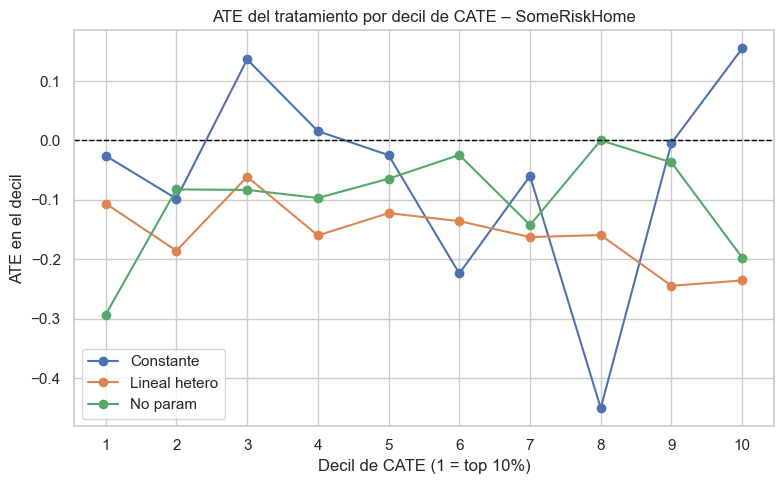

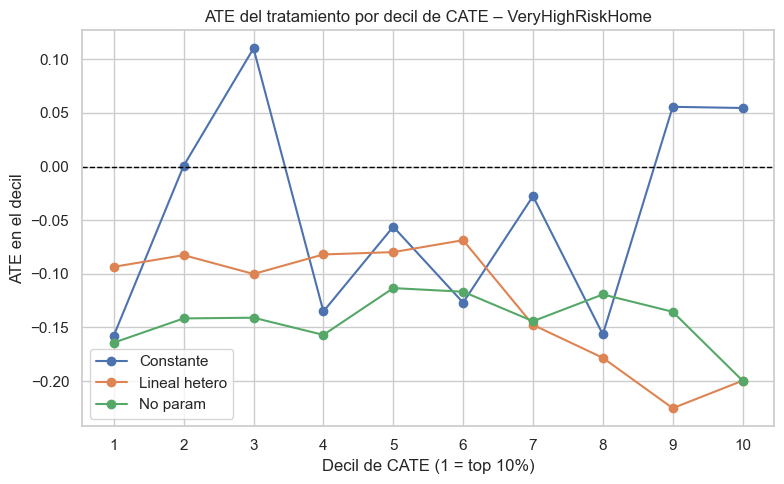

In [30]:
def ate_por_decil(y, t, cate, n_bins=10):
    """
    Ordena por cate (desc) y calcula ATE por decil:
      ATE_j = E[Y|T=1, decil j] - E[Y|T=0, decil j]
    """
    order = np.argsort(-cate)
    y = y[order]
    t = t[order]
    n = len(y)
    bin_size = n // n_bins

    ates = []
    deciles = []

    for j in range(n_bins):
        start = j * bin_size
        end = (j + 1) * bin_size if j < n_bins - 1 else n

        y_bin = y[start:end]
        t_bin = t[start:end]

        mask_t1 = (t_bin == 1)
        mask_t0 = (t_bin == 0)

        if mask_t1.sum() > 0 and mask_t0.sum() > 0:
            ate_j = y_bin[mask_t1].mean() - y_bin[mask_t0].mean()
        else:
            ate_j = np.nan

        deciles.append(j + 1)   # decil 1 = top 10% CATE
        ates.append(ate_j)

    return np.array(deciles), np.array(ates)


def plot_ate_por_decil(Y_col, n_bins=10):
    base = pd.DataFrame(index=df.index)
    base["y"] = df[Y_col]
    base["t"] = df[T_col]

    base["cate_const"]  = dml_lin_const_results[Y_col]["df"]["cate_dml_linear_const"].reindex(base.index)
    base["cate_hetero"] = dml_lin_hetero_results[Y_col]["df"]["cate_dml_linear_hetero"].reindex(base.index)
    base["cate_np"]     = dml_np_results[Y_col]["df"]["cate_dml_nonparam"].reindex(base.index)

    base = base.dropna(subset=["y", "t", "cate_const", "cate_hetero", "cate_np"])

    y   = base["y"].values.astype(float)
    t   = base["t"].values.astype(int)
    c_c = base["cate_const"].values.astype(float)
    c_h = base["cate_hetero"].values.astype(float)
    c_n = base["cate_np"].values.astype(float)

    d_c, ate_c = ate_por_decil(y, t, c_c, n_bins=n_bins)
    d_h, ate_h = ate_por_decil(y, t, c_h, n_bins=n_bins)
    d_n, ate_n = ate_por_decil(y, t, c_n, n_bins=n_bins)

    plt.figure(figsize=(8, 5))
    plt.plot(d_c, ate_c, marker="o", label="Constante",  color="C0")
    plt.plot(d_h, ate_h, marker="o", label="Lineal hetero", color="C1")
    plt.plot(d_n, ate_n, marker="o", label="No param",      color="C2")
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xticks(range(1, n_bins + 1))
    plt.title(f"ATE del tratamiento por decil de CATE – {Y_col}")
    plt.xlabel("Decil de CATE (1 = top 10%)")
    plt.ylabel("ATE en el decil")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Ejecutar para ambos outcomes
for y in outcomes:
    plot_ate_por_decil(y, n_bins=10)


In [33]:
def add_cate_decile_column(df, cate_col, n_bins=10):
    """
    Crea un decil (1..n_bins) a partir de cate_col, ordenando de mayor a menor CATE.
    """
    # rank inverso: 1 = mayor CATE
    df = df.copy()
    df["cate_rank"] = df[cate_col].rank(method="first", ascending=False)
    n = len(df)
    df["decile"] = np.ceil(df["cate_rank"] * n_bins / n).astype(int)
    df["decile"] = df["decile"].clip(1, n_bins)
    return df


def summary_by_decile(Y_col, model="np", n_bins=10):
    """
    Tabla de medias por decil de CATE para un modelo:
      model in {"const", "hetero", "np"}
    """
    # elige de qué df tomar el CATE
    if model == "const":
        src = dml_lin_const_results[Y_col]["df"]
        cate_col = "cate_dml_linear_const"
    elif model == "hetero":
        src = dml_lin_hetero_results[Y_col]["df"]
        cate_col = "cate_dml_linear_hetero"
    elif model == "np":
        src = dml_np_results[Y_col]["df"]
        cate_col = "cate_dml_nonparam"
    else:
        raise ValueError("model debe ser 'const', 'hetero' o 'np'")

    # unir outcome, tratamiento y X originales
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=True)
    base = df_ml.copy()
    base[cate_col] = src[cate_col].reindex(base.index)

    base = base.dropna(subset=[cate_col])

    # añadir decil
    base = add_cate_decile_column(base, cate_col, n_bins=n_bins)

    # columnas que quieres resumir (ejemplo: todas las X + T + Y)
    cols_to_summarize = [Y_col, T_col] + X_cols

    tabla = (
        base.groupby("decile")[cols_to_summarize]
        .mean()
        .reset_index()
        .sort_values("decile")
    )

    return tabla


# Ejemplo: tabla por decil para outcome y = outcomes[0], modelo no param
tabla_const = summary_by_decile(outcomes[0], model="const", n_bins=10)
tabla_hetero = summary_by_decile(outcomes[0], model="hetero", n_bins=10)
tabla_np = summary_by_decile(outcomes[0], model="np", n_bins=10)

display(tabla_const)
display(tabla_hetero)
display(tabla_np)


,decile,SomeRiskHome,water_treatment,windex5,country_cat,WS1_g,water_carrier_edu,helevel,Any_U5,Girls_less_than15,Boys_15or_less,Pit_latrine,Open_defecation
0,1,0.953702,0.054405,2.833003,9.607278,27.416862,60.475590,0.772473,0.525671,0.070258,0.039632,0.512881,0.412178
1,2,0.829040,0.042155,2.647991,6.263736,29.364799,89.902718,1.015493,0.633039,0.091515,0.026842,0.573951,0.384976
2,3,0.733922,0.093317,2.922176,11.991353,30.170599,63.085930,1.128265,0.502792,0.056747,0.031886,0.619708,0.113853
3,4,0.778779,0.328409,2.604756,17.240677,25.149523,47.520088,0.947397,0.486219,0.063412,0.019276,0.546928,0.381012
4,5,0.883465,0.072947,3.042147,24.024496,23.676693,33.821865,1.209654,0.476405,0.060339,0.013869,0.664625,0.207673
5,6,0.584940,0.517024,2.570708,23.584399,30.480635,82.303909,1.454333,0.302288,0.007026,0.002882,0.238516,0.096019
6,7,0.810304,0.092596,2.820573,2.809584,20.721132,87.170959,1.002702,0.328409,0.007746,0.000901,0.494505,0.017654
7,8,0.665826,0.416321,2.643668,21.110971,39.210411,62.385696,1.283913,0.388218,0.015313,0.018916,0.243380,0.118357
8,9,0.766889,0.167537,2.631778,13.038552,64.196899,90.503693,1.398307,0.301747,0.003063,0.001621,0.173122,0.107728
9,10,0.495317,0.211996,2.888148,20.792327,44.452991,93.234146,1.563220,0.302233,0.002882,0.002522,0.054215,0.056556


,decile,SomeRiskHome,water_treatment,windex5,country_cat,WS1_g,water_carrier_edu,helevel,Any_U5,Girls_less_than15,Boys_15or_less,Pit_latrine,Open_defecation
0,1,0.826183,0.127233,2.707789,7.927454,35.974220,83.269379,1.014914,0.386853,0.030565,0.009943,0.374333,0.223716
1,2,0.807034,0.148776,2.694716,9.887498,40.595470,82.043823,1.031302,0.456638,0.044007,0.018781,0.343215,0.286135
2,3,0.750690,0.195176,2.719757,11.893942,36.615540,77.493462,1.162033,0.412999,0.029092,0.013073,0.422390,0.135334
3,4,0.747560,0.238446,2.644264,13.446143,36.201435,74.397346,1.164795,0.440435,0.036642,0.013994,0.425520,0.180814
4,5,0.769472,0.171239,2.829681,14.628614,33.765972,71.790459,1.198858,0.448168,0.038299,0.015835,0.446511,0.185601
5,6,0.739827,0.201068,2.744062,14.975511,33.448536,74.121338,1.239367,0.449457,0.042534,0.019518,0.454428,0.179893
6,7,0.723992,0.249310,2.747008,16.037746,32.261646,69.892471,1.213405,0.419076,0.033327,0.013810,0.415393,0.159087
7,8,0.716627,0.236605,2.865771,16.974406,31.568771,68.350029,1.246363,0.409501,0.035168,0.016387,0.392193,0.159639
8,9,0.737986,0.259621,2.834837,19.985822,27.137913,57.750320,1.229240,0.417050,0.042349,0.018965,0.429203,0.202725
9,10,0.801878,0.163506,2.826367,21.842018,25.661757,45.538574,1.165347,0.458295,0.054686,0.021543,0.504879,0.224636


,decile,SomeRiskHome,water_treatment,windex5,country_cat,WS1_g,water_carrier_edu,helevel,Any_U5,Girls_less_than15,Boys_15or_less,Pit_latrine,Open_defecation
0,1,0.546568,0.726536,2.234012,23.902540,32.267700,63.591606,1.466943,0.396505,0.018195,0.025041,0.429292,0.133489
1,2,0.828860,0.338858,2.397586,16.783282,27.565664,69.059090,1.156368,0.445325,0.050622,0.028463,0.451630,0.137633
2,3,0.775356,0.167537,2.856963,14.916051,30.539362,74.045219,1.256170,0.415240,0.036210,0.008647,0.438840,0.083228
3,4,0.787786,0.126824,2.899478,12.341920,33.006485,81.327148,1.145920,0.377950,0.035669,0.009728,0.465502,0.142317
4,5,0.762068,0.101405,2.879323,12.166427,32.224422,80.704788,1.173811,0.406520,0.026297,0.004683,0.405079,0.170029
5,6,0.778058,0.076383,2.768510,12.022518,30.186453,76.565842,1.027202,0.422266,0.038011,0.003783,0.425329,0.219060
6,7,0.762745,0.111872,3.058908,11.943974,38.629616,77.250046,1.223563,0.488020,0.032246,0.004864,0.300306,0.249685
7,8,0.697532,0.095839,3.243740,14.013871,44.112591,78.059990,1.228067,0.313997,0.028103,0.004324,0.328589,0.172762
8,9,0.794451,0.096559,2.683120,15.251666,34.360294,60.709782,1.015673,0.480454,0.038191,0.009007,0.434156,0.270582
9,10,0.768732,0.154899,2.583393,17.123919,31.948668,49.090599,1.082133,0.500720,0.074748,0.059798,0.443084,0.317183


Para cada modelo, los deciles son definidos por el **CATE estimado** y dentro de cada decil miras el **promedio de características del hogar** (incluyendo riesgo y acceso a agua).

## Modelo DML lineal constante

- **Decil 1 (top CATE)**  
  - Hogares con riesgo extremadamente alto: `SomeRiskHome ≈ 0.95`.  
  - Casi sin tratamiento: `water_treatment ≈ 0.05`.  
  - Condiciones materiales y de saneamiento muy malas: riqueza intermedia-baja (`windex5 ≈ 2.8`), alta proporción con letrina precaria (`Pit_latrine ≈ 0.51`) y defecación abierta (`Open_defecation ≈ 0.41`).  
  - Interpretable como: el modelo identifica como mayor beneficio marginal a hogares **muy vulnerables, poco tratados y con peor infraestructura**.

- **Deciles medios (4–6)**  
  - Riesgo sigue alto (`SomeRiskHome ≈ 0.78–0.88`), pero el acceso a tratamiento sube bastante en algunos deciles (`water_treatment` hasta ≈ 0.52).  
  - `Pit_latrine` y `Open_defecation` bajan respecto al decil 1 en ciertos tramos.  
  - El modelo sigue viendo efecto positivo, pero ya mezcla hogares más heterogéneos: riesgo alto pero con algo más de tratamiento y algo mejores condiciones.

- **Decil 10 (bottom CATE)**  
  - Menor riesgo (`SomeRiskHome ≈ 0.49`).  
  - Mayor acceso a agua segura (`water_treatment ≈ 0.21`).  
  - Riqueza y educación del portador más altas, y casi sin saneamiento precario (`Pit_latrine ≈ 0.05`, `Open_defecation ≈ 0.06`).  
  - Es decir, el modelo constante considera de **baja prioridad** a hogares relativamente mejor situados.

**Clave:** este modelo ordena bastante **por vulnerabilidad**: top deciles = más riesgo, menos tratamiento, peor saneamiento; bottom deciles = mejor situación.

***

## Modelo DML lineal heterogéneo

- **Decil 1 (top CATE)**  
  - Riesgo alto (`SomeRiskHome ≈ 0.83`), tratamiento ya algo mayor que en el modelo constante (`water_treatment ≈ 0.13`).  
  - Saneamiento intermedio (`Pit_latrine ≈ 0.37`, `Open_defecation ≈ 0.22`).  
  - El modelo sigue priorizando hogares vulnerables, pero menos extremos (no son los absolutamente peor servidos).

- **Deciles medios (4–7)**  
  - `SomeRiskHome ≈ 0.74–0.77`, `water_treatment ≈ 0.20–0.25`.  
  - Riqueza y contexto se mantienen bastante estables a lo largo de deciles; `Pit_latrine` ronda 0.42–0.46, `Open_defecation ≈ 0.16–0.19`.  
  - La CATE se reparte más suavemente a lo largo del gradiente socioeconómico: no sólo en los extremos más pobres.

- **Decil 10 (bottom CATE)**  
  - Riesgo sigue alto (`SomeRiskHome ≈ 0.80`), tratamiento ≈ 0.16.  
  - Características de país/barrio diferentes (país y `WS1_g` más altos, mejor contexto urbano), y saneamiento no necesariamente peor.  
  - Algunos hogares de alto riesgo pero en mejor contexto acaban con CATE relativamente baja.

**Clave:** el modelo lineal heterogéneo captura que el efecto del tratamiento varía no sólo con pobreza extrema sino también con **contexto de país/barrio**; distribuye el efecto a lo largo de perfiles más diversos.

***

## Modelo DML no paramétrico (weight trick)

- **Decil 1 (top CATE)**  
  - Riesgo moderado-alto (`SomeRiskHome ≈ 0.55`), pero con **tratamiento muy alto** (`water_treatment ≈ 0.73`).  
  - Saneamiento todavía malo (`Pit_latrine ≈ 0.43`), pero defecación abierta bastante menor que en el modelo constante (`≈ 0.13`).  
  - El modelo asigna CATE alto a lugares donde el tratamiento **ya está muy presente**, lo que sugiere que está premiando contextos donde el tratamiento parece funcionar bien (efectos incrementales grandes), no necesariamente donde falta.

- **Deciles medios (4–7)**  
  - Riesgo alto (`SomeRiskHome ≈ 0.76–0.79`), tratamiento más bajo (`≈ 0.10–0.13`).  
  - Riqueza algo mayor (`windex5 ≈ 2.77–3.06`), buena educación del portador y saneamiento algo mejor que en el constante.  
  - El modelo NP tiende a priorizar hogares de alto riesgo pero con **condiciones estructurales algo mejores**, no los más marginales.

- **Decil 10 (bottom CATE)**  
  - Riesgo sigue alto (`SomeRiskHome ≈ 0.77`), tratamiento ≈ 0.15.  
  - Saneamiento no mejora claramente (`Open_defecation ≈ 0.32`), y pobreza no es mínima.  
  - La separación “vulnerables vs no vulnerables” es menos nítida: hay hogares bastante pobres y con mal saneamiento en deciles bajos.

**Clave:** el modelo no paramétrico parece aprender patrones donde el tratamiento tiene **alto efecto marginal condicionado al contexto**, pero ese contexto no coincide uno a uno con “máxima pobreza”; mezcla vulnerabilidad con “tratamiento ya presente” y condiciones donde la intervención es más eficaz.

***

## Resumen comparado

| Modelo | Quién queda en top deciles de CATE | Mensaje práctico |
|--------|------------------------------------|------------------|
| Constante | Hogares más pobres, con mayor riesgo y menor acceso a agua, peor saneamiento | Fuerte enfoque en **vulnerabilidad material** |
| Lineal heterogéneo | Hogares de alto riesgo, pero repartidos según país/barrio y covariables; extremos menos marcados | Segmentación más **suave** y más sensible al contexto |
| No paramétrico | Hogares donde el tratamiento ya es frecuente y el contexto parece favorecer un gran efecto | Enfatiza **eficacia marginal** del tratamiento más que falta de cobertura |

Esto te permite decidir si quieres un modelo que priorice **los más vulnerables** (constante), uno más balanceado por contexto (heterogéneo) o uno que maximice **impacto marginal donde el tratamiento “pega” más** (no paramétrico), aun si eso no coincide perfectamente con pobreza extrema.